# Predicting Wine Price from Review Text with ModernBERT

`description` のみから $\log(\mathrm{price})$ を予測する回帰モデルです。英語・コードで事前学習された [`answerdotai/ModernBERT-base`](https://huggingface.co/answerdotai/ModernBERT-base) を Hugging Face `Trainer` でfine-tuningします。

### 実行コードの説明

ファイル操作、データ処理、可視化、GPU処理、Hugging Face Dataset、評価指標、ModernBERTのfine-tuningに必要なライブラリを読み込む。`AutoTokenizer` は文章をトークン列へ変換し、`AutoModelForSequenceClassification` は回帰ヘッド付きモデルとして使用する。乱数シードを42に固定し、データ分割などの再現性を確保する。


In [11]:
# 必要なライブラリが未インストールの場合のみ、次の行のコメントを外してください。
# %pip install -q -U "transformers>=4.48.0" datasets accelerate scikit-learn

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset, DatasetDict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

sns.set_theme(style="whitegrid")
SEED = 42

## 1. データの読み込みと重複除外

同じレビュー本文が訓練データと評価データに分かれないよう、`description` が重複する行を除外します。価格が欠損または非正の行も除外します。

### 実行コードの説明

CSVを `data/` または `../data/` から探索して読み込む。本文が欠損した行、価格が欠損または非正の行を除き、同じ `description` を持つ重複レビューを削除する。本文列を `text`、価格の自然対数を `float32` の `label` とし、対象行数、先頭データ、目的変数の分布を表示する。


In [ ]:
filename = "winemag-data-130k-v2.csv"
candidate_paths = [Path("data") / filename, Path("../data") / filename]
csv_path = next((path for path in candidate_paths if path.exists()), None)

if csv_path is None:
    searched = "\n".join(f"- {path.resolve()}" for path in candidate_paths)
    raise FileNotFoundError(f"CSV が見つかりません。以下を確認してください。\n{searched}")

df = pd.read_csv(csv_path)
rows_before = len(df)

model_data = (
    df.loc[
        df["description"].notna()
        & df["price"].notna()
        & (df["price"] > 0),
        ["description", "price"],
    ]
    .drop_duplicates(subset=["description"])
    .rename(columns={"description": "text"})
    .reset_index(drop=True)
)
model_data["label"] = np.log(model_data["price"]).astype("float32")

print(f"Loaded: {csv_path.resolve()}")
print(f"Original rows: {rows_before:,}")
print(f"Rows used after filtering and deduplication: {len(model_data):,}")
display(model_data.head())
display(model_data["label"].describe().rename("log_price").to_frame())

### `description` の文字数分布

重複除外と価格フィルタリング後のレビュー本文について、文字数の要約統計と分布を確認します。

### 実行コードの説明

レビュー本文の文字数を行ごとに計算し、平均、標準偏差、四分位点、90・95・99パーセンタイル、最大値を表示する。ヒストグラムには中央値を破線で示す。この文字数分布は、後続の最大トークン長を検討する参考になるが、文字数とトークン数は同一ではない。


,description_length
count,111567.000000
mean,244.477328
std,67.187402
min,20.000000
50%,239.000000
75%,285.000000
90%,331.000000
95%,362.000000
99%,431.000000
max,829.000000


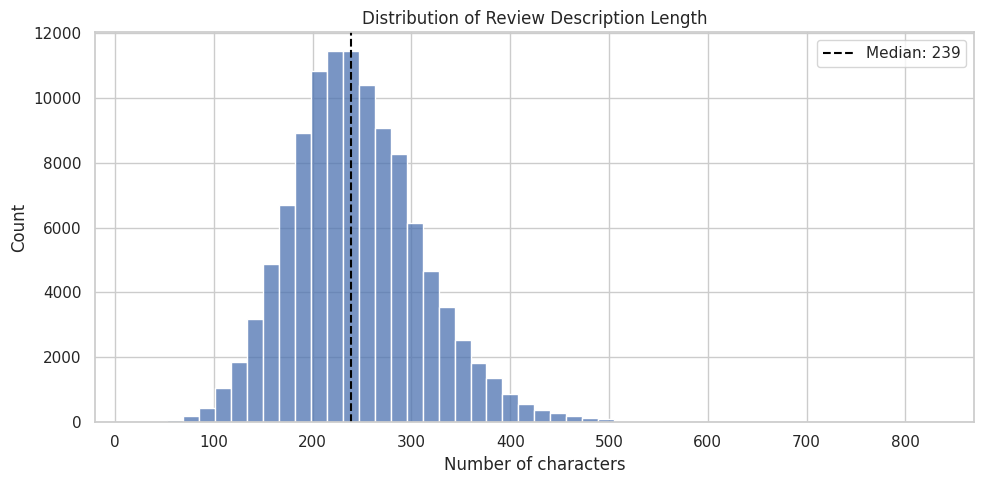

In [13]:
description_length = model_data["text"].str.len()
length_summary = description_length.describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).rename("description_length")
display(length_summary.to_frame())

plt.figure(figsize=(10, 5))
sns.histplot(description_length, bins=50, color="#4C72B0")
plt.axvline(
    description_length.median(),
    color="black",
    linestyle="--",
    label=f"Median: {description_length.median():.0f}",
)
plt.title("Distribution of Review Description Length")
plt.xlabel("Number of characters")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


## 2. ModernBERT の準備とデータ分割

80%を訓練、10%を検証、10%を最終テストに使います。動作確認だけを短時間で行いたい場合は `MAX_ROWS` に行数を指定してください。

### 実行コードの説明

`answerdotai/ModernBERT-base` のtokenizerと回帰モデルを読み込む。`num_labels=1` と `problem_type="regression"` により出力を1つの連続値にする。必要なら `MAX_ROWS` でデータを固定乱数抽出し、その後Hugging Face Datasetへ変換する。データを80%の訓練、10%の検証、10%のテストに分割し、各件数を表示する。


In [14]:
MODEL_NAME = "answerdotai/ModernBERT-base"
MAX_LENGTH = 256
MAX_ROWS = None  # 例: 10_000。全データを使う場合は None

if MAX_ROWS is not None and len(model_data) > MAX_ROWS:
    model_data = model_data.sample(MAX_ROWS, random_state=SEED).reset_index(drop=True)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=1,
    problem_type="regression",
)

dataset = Dataset.from_pandas(
    model_data[["text", "label"]], preserve_index=False
)
train_holdout = dataset.train_test_split(test_size=0.2, seed=SEED)
valid_test = train_holdout["test"].train_test_split(test_size=0.5, seed=SEED)
dataset = DatasetDict({
    "train": train_holdout["train"],
    "validation": valid_test["train"],
    "test": valid_test["test"],
})

print(dataset)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 89253
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 11157
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 11157
    })
})


## 3. Tokenization

### 実行コードの説明

各レビュー本文をModernBERTのtokenizerでトークン化する。`MAX_LENGTH=256` は文字数ではなく特殊トークンを含む最大トークン数であり、超過部分は末尾から切り詰める。全データをbatch処理し、元の文字列列を削除して `input_ids`、`attention_mask`、`label` を持つ学習用Datasetを作る。paddingはTrainerがbatch作成時に行う。


In [15]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )


tokenized_dataset = dataset.map(
    tokenize,
    batched=True,
    remove_columns=["text"],
)
tokenized_dataset

Map:   0%|          | 0/89253 [00:00<?, ? examples/s]

Map:   0%|          | 0/11157 [00:00<?, ? examples/s]

Map:   0%|          | 0/11157 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 89253
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 11157
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 11157
    })
})

## 4. 評価指標

学習時の損失とRMSE・MAE・$R^2$ は log価格で計算します。参考として、ドル価格に戻したMAEも計算します。

### 実行コードの説明

Hugging Face `Trainer` が検証・評価時に呼び出す指標計算関数を定義する。モデル出力と正解ラベルを1次元へ整形し、log価格のRMSE、MAE、$R^2$ を計算する。さらに両者を指数変換してドル価格へ戻し、価格単位のMAEも返す。


In [16]:
def compute_metrics(eval_prediction):
    predictions = np.asarray(eval_prediction.predictions).reshape(-1)
    labels = np.asarray(eval_prediction.label_ids).reshape(-1)
    return {
        "rmse": mean_squared_error(labels, predictions) ** 0.5,
        "mae": mean_absolute_error(labels, predictions),
        "r2": r2_score(labels, predictions),
        "price_mae_usd": mean_absolute_error(
            np.exp(labels), np.exp(predictions)
        ),
    }

## 5. Fine-tuning

GPUが利用可能な場合は mixed precision (`fp16`) を有効にします。検証RMSEが改善しない状態が2回続いた場合は学習を停止します。

### 実行コードの説明

fine-tuningの学習率、batch size、最大10 epoch、正則化、warmup、評価・保存頻度を設定する。勾配を2 step蓄積するため、1 deviceあたりの実効訓練batch sizeは16×2となる。GPUがあればfp16を使い、各epochの検証RMSEで最良モデルを選ぶ。RMSEが2回連続で改善しなければearly stoppingし、最後に最良時点の重みを復元する。


In [17]:
training_args = TrainingArguments(
    output_dir="./wine-review-modernbert",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    num_train_epochs=10,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="rmse",
    greater_is_better=False,
    save_total_limit=1,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Rmse,Mae,R2,Price Mae Usd
1,0.495029,0.240227,0.490130,0.370487,0.463061,14.725263
2,0.389817,0.211947,0.460378,0.349053,0.526270,13.987393
3,0.326136,0.229202,0.478750,0.373800,0.487704,15.279020


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 6. テストデータでの最終評価

### 実行コードの説明

学習やearly stoppingに使っていないテストDatasetを、最良モデルで評価する。`metric_key_prefix="test"` により、loss、RMSE、MAE、$R^2$、ドル価格MAEなどへ `test_` 接頭辞を付け、表形式で表示する。これが未知データに対する最終性能指標となる。


In [18]:
test_metrics = trainer.evaluate(
    eval_dataset=tokenized_dataset["test"],
    metric_key_prefix="test",
)
display(pd.Series(test_metrics, name="value").to_frame())

Epoch,Training Loss,Validation Loss,Rmse,Mae,R2,Price Mae Usd
1,0.495029,0.240227,0.490130,0.370487,0.463061,14.725263
2,0.389817,0.211947,0.460378,0.349053,0.526270,13.987393
3,0.326136,0.202883,0.450426,0.346647,0.531362,13.392219


[transformers] early stopping required metric_for_best_model, but did not find eval_rmse so early stopping is disabled


,value
test_loss,0.202883
test_rmse,0.450426
test_mae,0.346647
test_r2,0.531362
test_price_mae_usd,13.392219


### 予測値と残差を可視化するコード

テストデータ全件の予測を取得し、実際のlog価格、予測log価格、残差を作る。左図は実測値と予測値を45度線と比較し、右図は「実際値 − 予測値」の分布を表示する。45度線からの距離、残差の中心のずれ、長い裾から、誤差の大きさや系統的な過大・過小予測を確認する。


Epoch,Training Loss,Validation Loss,Rmse,Mae,R2,Price Mae Usd
1,0.495029,0.240227,0.490130,0.370487,0.463061,14.725263
2,0.389817,0.211947,0.460378,0.349053,0.526270,13.987393
3,0.326136,0.202883,0.450426,0.346647,0.531362,13.392219


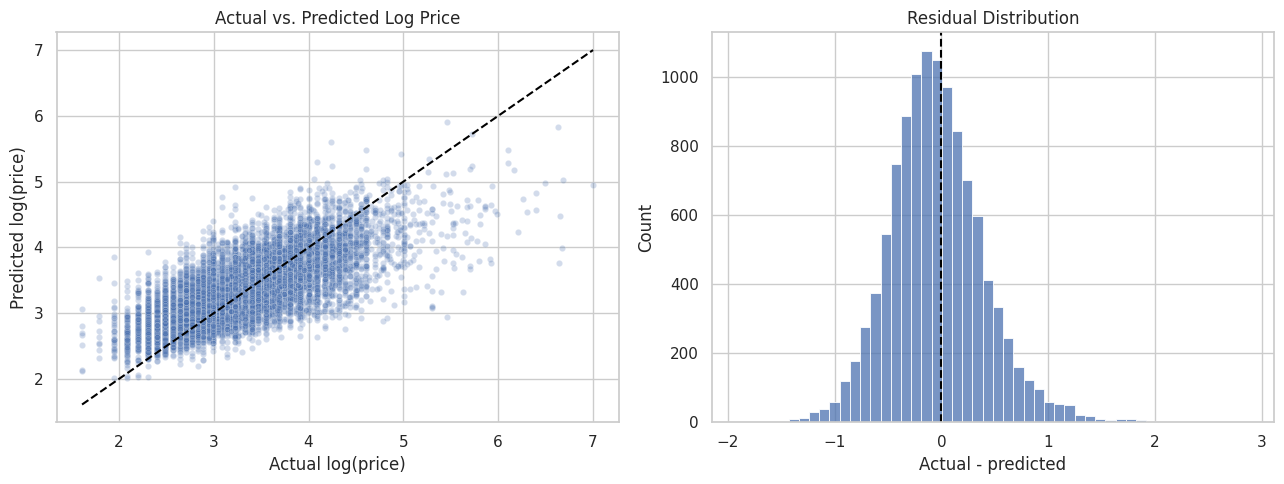

In [19]:
test_output = trainer.predict(tokenized_dataset["test"])
actual_log_price = np.asarray(test_output.label_ids).reshape(-1)
predicted_log_price = np.asarray(test_output.predictions).reshape(-1)
residuals = actual_log_price - predicted_log_price

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(
    x=actual_log_price,
    y=predicted_log_price,
    alpha=0.25,
    s=20,
    ax=axes[0],
)
limits = [
    min(actual_log_price.min(), predicted_log_price.min()),
    max(actual_log_price.max(), predicted_log_price.max()),
]
axes[0].plot(limits, limits, "--", color="black")
axes[0].set(
    title="Actual vs. Predicted Log Price",
    xlabel="Actual log(price)",
    ylabel="Predicted log(price)",
)

sns.histplot(residuals, bins=50, ax=axes[1])
axes[1].axvline(0, linestyle="--", color="black")
axes[1].set(title="Residual Distribution", xlabel="Actual - predicted")

plt.tight_layout()
plt.show()

## 7. 新しいレビュー本文から価格を予測

### 実行コードの説明

任意のレビュー本文1件をtokenizeし、学習済みモデルと同じdeviceへ転送して推論する関数を定義する。評価モードと `torch.no_grad()` によりdropoutと勾配計算を無効化し、予測したlog価格と、それを指数変換したドル価格を返す。最後に例文を入力して関数の使用例を表示する。


In [20]:
def predict_price(description):
    inputs = tokenizer(
        description,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    ).to(model.device)
    model.eval()
    with torch.no_grad():
        predicted_log_price = model(**inputs).logits.squeeze().item()
    return {
        "log_price": predicted_log_price,
        "price_usd": float(np.exp(predicted_log_price)),
    }


example = (
    "A rich and structured red wine with ripe blackberry, dark chocolate, "
    "cedar and a long, balanced finish."
)
print(predict_price(example))

{'log_price': 3.298828125, 'price_usd': 27.080884906424416}


## 注意点

レビュー本文には価格帯を示唆する表現やワイン固有情報が含まれる可能性があります。このモデルが評価するのは、レビュー本文が既に得られている条件での価格予測です。また、ランダム分割の結果は未知の生産者・地域への性能を保証しません。